In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
from google.colab import files


In [3]:
# ==========================================
# 1. DATASET UPLOAD AND EXTRACTION
# ==========================================
print("Step 1: Please upload your 'dataset.zip' file.")
uploaded = files.upload()

# Extract the dataset
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(".")

# Define paths and constants
DATASET_PATH = "dataset" # Ensure your zip contains a folder named 'dataset'
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS_INITIAL = 20
EPOCHS_FINE_TUNE = 15

Step 1: Please upload your 'dataset.zip' file.


Saving dataset.zip to dataset (1).zip


In [6]:
# ==========================================
# 2. DATA PREPROCESSING AND AUGMENTATION
# ==========================================
# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescaling for validation data
val_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' # Assuming the dataset has a training subset or structure
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation' # Assuming the dataset has a validation subset or structure
)

# Get class names from the training data generator
class_names = list(train_data.class_indices.keys())
print(f"Detected {len(class_names)} classes: {class_names}")


Found 60 images belonging to 3 classes.
Found 0 images belonging to 3 classes.
Detected 3 classes: ['Amritmahal', 'Gir', 'Sahiwal']


In [9]:
# ==========================================
# 3. MODEL BUILDING (DENSENET121)
# ==========================================
# Upgrading from MobileNetV2 to DenseNet121 for higher accuracy with more breeds
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Freeze base for initial training

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x) # Increased units for complex breed patterns
x = Dropout(0.4)(x) # Helps prevent overfitting in multi-class scenarios
output = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [12]:
# ==========================================
# 4. TRAINING STAGE 1: CLASSIFIER HEAD
# ==========================================
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
print("\nStarting Stage 1: Training the Classifier Head...")
model.fit(train_data, epochs=EPOCHS_INITIAL)


Starting Stage 1: Training the Classifier Head...
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5829 - loss: 1.0699
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6683 - loss: 0.7894
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6987 - loss: 0.5514
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8813 - loss: 0.3831
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8873 - loss: 0.4191
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7892 - loss: 0.3733
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8914 - loss: 0.3882
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8658 - loss: 0.2313
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9284 - loss: 0.2009
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8827 - loss: 0.2375
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9459 - loss: 0.2298
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step

In [15]:
# ==========================================
# 5. TRAINING STAGE 2: FINE-TUNING
# ==========================================
base_model.trainable = True
# Freeze early layers, keep last 30 layers trainable to adapt to livestock features
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5), # Very low learning rate for stability
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting Stage 2: Fine-Tuning the Model...")
model.fit(train_data, epochs=EPOCHS_FINE_TUNE)

# Save the final model
model.save("indian_livestock_model.h5")
print("Model saved successfully as indian_livestock_model.h5")


Starting Stage 2: Fine-Tuning the Model...
Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8461 - loss: 0.3930
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.8150 - loss: 0.4092
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.7900 - loss: 0.3599
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8090 - loss: 0.4275
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8617 - loss: 0.3588
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9271 - loss: 0.2056
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8981 - loss: 0.1925
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9181 - loss: 0.2086
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.9387 - loss: 0.1570
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.8904 - loss: 0.2266
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9479 - loss: 0.1710
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - a

Model saved successfully as indian_livestock_model.h5



--- Testing the Model ---
Please upload an image for breed prediction:


Saving 2.jpeg to 2 (2).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


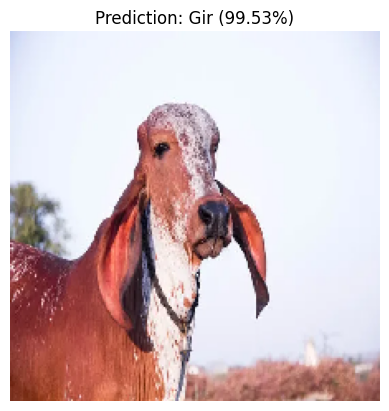

Predicted Breed: Gir
Confidence: 99.53%


In [21]:
# ==========================================
# 6. PREDICTION ON NEW IMAGE
# ==========================================
print("\n--- Testing the Model ---")
print("Please upload an image for breed prediction:")
test_upload = files.upload()

for img_path in test_upload.keys():
    # Load and preprocess image
    test_img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(test_img)
    img_array = img_array / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)[0]
    confidence = np.max(predictions) * 100
    predicted_breed = class_names[np.argmax(predictions)]

    # Visualization
    plt.imshow(test_img)
    plt.title(f"Prediction: {predicted_breed} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Predicted Breed: {predicted_breed}")
    print(f"Confidence: {confidence:.2f}%")